<a href="https://colab.research.google.com/github/chenyujiedev/Advanced-Algorithm-Design-and-Analysis-50070-/blob/main/langchain%E2%80%940_3_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 먼저 Google Drive를 마운트해야 합니다. 그렇지 않으면 뒤따르는 스크립트가 파일을 읽을 수 없습니다.
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
# 미리 작성해 둔 Ollama 시작 스크립트를 실행합니다. 매번 수동으로 설정하기 귀찮아서요.
%run "/content/drive/MyDrive/GJ/Ollama_script.ipynb"

>>> 구글 드라이브를 연결합니다...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
>>> 연결 완료: /root/.ollama -> /content/drive/MyDrive/Colab Notebooks/LLM/ollama_config
>>> Ollama 설치를 시작합니다...
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3build1).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
>>> Ollama 서버를 실행합니다...
>>> 모든 설정이 완료되었습니다!



In [ ]:
# llama3.1을 다운로드하세요. 처음에는 다소 시간이 걸릴 수 있습니다.
!ollama pull llama3.1

In [ ]:
# langchain 설치, -U 옵션을 사용하여 최신 버전이 설치되도록 합니다
!pip install -U langchain

In [ ]:
# # langchain-community를 설치한 후, ChatOllama를 사용하여 로컬 llama3.1을 채팅 모델로 묶습니다
!pip install -U langchain-ollama
from langchain_ollama import ChatOllama
model = ChatOllama(
    model="llama3.1"
    )

In [ ]:
# 테스트를 실행해 볼게요. 1+1을 계산해 보고 모델이 정상적으로 작동하는지 확인해 볼게요.
response = model.invoke("1+1等于多少")

In [ ]:
# 한 번 인쇄해서 확인해 보세요
response

AIMessage(content='1+1=2', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-04-19T08:06:35.275825437Z', 'message': {'role': 'assistant', 'content': ''}, 'done': True, 'done_reason': 'stop', 'total_duration': 224046811512, 'load_duration': 223808465536, 'prompt_eval_count': 16, 'prompt_eval_duration': 71856372, 'eval_count': 6, 'eval_duration': 149773862}, id='lc_run--019da4c3-88da-78a3-9624-93f4d2ec78f7-0', tool_calls=[], invalid_tool_calls=[])

In [ ]:
# 질문 몇 개를 미리 준비해 두었다가, 나중에 모델에 한꺼번에 던져주면 하나씩 조정할 필요가 없겠네요.
inputs = ["你好", "今天釜山天气怎么样？", "帮我随便写一首诗"]

In [ ]:
# 일괄 호출을 통해 모든 문제를 한 번에 전송
ans = model.batch(inputs)

In [ ]:
# 일괄 처리 결과를 훑어보며 본문만 출력하세요. 그렇지 않으면 그 많은 메타데이터가 보기 거슬리니까요.
for i, res in enumerate(ans):
    print(f"{res.content}")

您好！我可以幫助您什麼嗎？
我不知道你所在的地方的天气情况。
当然可以！需要什么主题或内容吗？


In [ ]:
# pydantic을 불러오고, 잠시 후 구조화된 출력용 데이터 형식을 정의하겠습니다
from pydantic import BaseModel, Field

In [ ]:
# people 클래스를 정의하고, 모델이 이름, 나이, 성별 순서로 출력하도록 지시합니다.
class people(BaseModel):
  name: str = Field(description="名字")
  age: int = Field(description="年龄")
  gender: str = Field(description="性别")

In [ ]:
# 모델에 구조화된 출력 방식을 적용하여, 결과가 반환될 때 ‘people’ 스키마에 맞춰 자동으로 정렬되도록 한다
model_output = model.with_structured_output(people)

In [ ]:
# 구조화된 모델을 실행해 보고, name/age/gender를 추출할 수 있는지 확인해 봅시다
response=model_output.invoke("介绍一下习近平")

In [ ]:
# 반환된 값이 실제로 people 객체인지, 속성이 올바른지 확인
response

people(name='习近平', age=68, gender='male')

In [ ]:
# @tool 데코레이터를 사용하여 날씨 조회 도구를 정의할 때, docstring은 매우 중요합니다. 모델은 이를 통해 언제 호출해야 하는지 파악합니다.
from langchain.tools import tool
@tool
def get_weather(location:str)->str:
 """提供特定区域的天气信息"""#dociment String,hint
 return f"{location}天气good，天气30度."

In [ ]:
from langchain_ollama import ChatOllama
from langgraph.prebuilt import create_react_agent

/tmp/ipykernel_1636/1826866427.py:1: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_model=create_react_agent(model,tools=[get_weather])


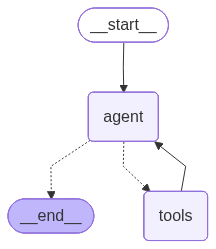

In [ ]:
# tool calling을 지원하는 langchain_ollama로 교체하고, ReAct Agent 프레임워크도 함께 도입
agent_model=create_react_agent(model,tools=[get_weather])
agent_model

In [ ]:
# ReAct Agent를 생성하여 모델과 도구를 연결하고, 도구를 호출할 시점을 자동으로 결정하도록 설정합니다.
!ollama run llama3.1

>>> Send a message (/? for help)^C


In [ ]:
import subprocess
# 백그라운드에서 ollama 서버 시작
subprocess.Popen(["ollama", "serve"])

Ollama server 启动完成！


In [ ]:
# Agent를 사용하여 날씨를 물어보기
result=agent_model.invoke(
  {
      "messages":[
         {
             "role":"user",
             "content":"中国北京现在的天气怎么样"
         }
      ]
  }

)

In [ ]:
# 인쇄 결과
result

{'messages': [HumanMessage(content='中国北京现在的天气怎么样', additional_kwargs={}, response_metadata={}, id='551262b5-2e37-41f8-a48f-e782ebf1633d'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-04-19T08:39:25.26774173Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4148090230, 'load_duration': 3250988723, 'prompt_eval_count': 155, 'prompt_eval_duration': 406511877, 'eval_count': 18, 'eval_duration': 431079755, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019da4e4-f318-7423-bd61-9e657f640d39-0', tool_calls=[{'name': 'get_weather', 'args': {'location': '中国北京'}, 'id': 'd573fd90-6fda-4d55-ac1c-872df2139cc1', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 155, 'output_tokens': 18, 'total_tokens': 173}),
  ToolMessage(content='中国北京天气good，天气30度.', name='get_weather', id='5383e29a-f5c9-4cd4-aed2-967e740346f2', tool_call_id='d573fd90-6fda-4d55-ac1c-872df2139cc1'),
